# Decorators

In [ ]:
def add(a,b):
    return a +b

def deco_func(func):
    def wrapper(*args, **kwargs):
        print("Now I am being decorated")
        func(*args, **kwargs)
    return wrapper

adding = deco_func(add)
print(adding(2, 3))

Now I am being decorated
None


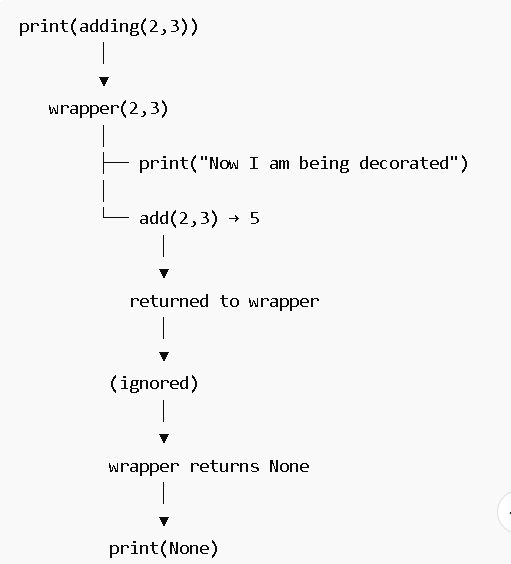

In [ ]:
def add(a,b):
    a + b

In [21]:
add(2, 3)

In [22]:
def add(a,b):
    return a +b

def deco_func(func):
    def wrapper(*args, **kwargs):
        print("Now I am being decorated")
        return func(*args, **kwargs)
    return wrapper

adding = deco_func(add)
print(adding(2, 3))

Now I am being decorated
5


In [23]:
def add(a, b):
    return a + b

print("Original add id:", id(add))


def deco_func(func):
    print("Decorator received function id:", id(func))

    def wrapper(*args, **kwargs):
        print("Wrapper id:", id(wrapper))
        print("Function inside wrapper id:", id(func))
        print("Now I am being decorated")
        result = func(*args, **kwargs)
        return result

    print("Wrapper created with id:", id(wrapper))
    return wrapper


adding = deco_func(add)

print("adding id:", id(adding))

print(adding(2, 3))

Original add id: 2354247286624
Decorator received function id: 2354247286624
Wrapper created with id: 2354247273664
adding id: 2354247273664
Wrapper id: 2354247273664
Function inside wrapper id: 2354247286624
Now I am being decorated
5


In [26]:
def deco_func(func):
    def wrapper(*args, **kwargs):
        print("Now I am being decorated")
        return func(*args, **kwargs)
    return wrapper

In [27]:
@deco_func
def add(a,b):
    return a+b

In [28]:
add(5, 6)

Now I am being decorated


11

# Map Function

In [61]:
def sq(a):
    return a**2

results = map(sq, [2, 3])

for result in results:
    print(result)

4
9


In [60]:
def multiply(a, b):
    return a * b

results = list(map(lambda x:multiply(*x), [(2, 3), (2,4)]))


print(results)

[6, 8]


# Filter Function

In [55]:
def find(x):
    if x > 2:
        return x
    
print(list(filter(find, [2, 2, 3])))

[3]


# Reduce Function

In [59]:
from functools import reduce
def multiply(a, b):
    return a * b

print(reduce(multiply, [1, 2, 3, 4]))

24


In [66]:
import numpy as np
import pandas as pd

np.random.seed(42)

N = 5000

data = pd.DataFrame({

    "temperature": np.random.normal(30,2,N),
    "pH": np.random.normal(7,0.5,N),
    "agitation_rpm": np.random.normal(500,80,N),
    "aeration_vvm": np.random.uniform(0.5,2,N),

    "fermentation_time": np.random.normal(24,4,N),

    "carbon_source_gL": np.random.uniform(20,60,N),
    "nitrogen_source_gL": np.random.uniform(5,20,N),

    "biomass_OD": np.random.uniform(20,80,N),

    "expression_rate": np.random.uniform(0.1,0.4,N),

    "centrifuge_speed": np.random.uniform(5000,15000,N),

    "lysis_efficiency": np.random.uniform(0.6,0.95,N),

    "precipitation_pH": np.random.uniform(4,7,N),

    "salt_concentration_M": np.random.uniform(0.5,2,N),

    "UF_pressure": np.random.uniform(10,30,N),

    "membrane_cutoff_kDa": np.random.choice([10,30,50],N),

    "chromatography_recovery": np.random.uniform(0.5,0.9,N)

})

# fermentation protein production

data["protein_expression"] = (
    data["biomass_OD"]
    * data["expression_rate"]
)

# released protein after lysis

data["released_protein"] = (
    data["protein_expression"]
    * data["lysis_efficiency"]
)

# precipitation efficiency

precip_eff = 0.7 + (data["precipitation_pH"]-5)*0.05

# UF efficiency

UF_eff = 0.8 - (data["UF_pressure"]-20)*0.005

# overall recovery

recovery = precip_eff * UF_eff * data["chromatography_recovery"]

# final protein

data["final_protein_recovered"] = (
    data["released_protein"]
    * recovery
)

data = data.drop(columns=["protein_expression","released_protein"])

print(data.head())

data.to_csv("fermentation_protein_dataset.csv", index=False)

   temperature        pH  agitation_rpm  aeration_vvm  fermentation_time  \
0    30.993428  6.788120     445.720422      1.084393          22.338198   
1    29.723471  6.773293     475.560043      0.522661          18.654672   
2    31.295377  6.102178     452.209515      1.847410          16.244800   
3    33.046060  6.834955     508.833444      1.290566          19.458223   
4    29.531693  7.366415     595.774283      1.774703          26.569898   

   carbon_source_gL  nitrogen_source_gL  biomass_OD  expression_rate  \
0         31.328625           11.495648   52.477804         0.372224   
1         31.494295            6.341088   27.411436         0.384905   
2         29.346242           19.972278   70.520910         0.393935   
3         33.756128           16.326282   70.726876         0.369681   
4         54.866991           14.321797   37.970343         0.395767   

   centrifuge_speed  lysis_efficiency  precipitation_pH  salt_concentration_M  \
0      13339.641463          